---
# COSC2753 | Machine Learning

## Task 0: Data Audit and Exploratory Data Analysis
---

# 1. Introduction

This notebook creates the shared evidence and data contract for every model. It audits metadata and images, detects exact duplicates, studies imbalance and target relationships, creates one group-isolated frozen split, and computes training-only RGB statistics. Run and review it before Tasks 1–4.

# 2. Library Imports and Setup

In [1]:
from pathlib import Path
import hashlib, json, os, sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import normalized_mutual_info_score
from sklearn.model_selection import GroupShuffleSplit

from preprocessing import (
    IMAGE_AUDIT_PATH, IMAGE_SIZE, NORMALISATION_PATH, OUTPUT_DIR, SEED, SPLIT_PATH, TARGETS,
    load_metadata, load_prediction_template, preprocess_image,
)
sns.set_theme(style='whitegrid')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 3. Metadata and Coverage Audit

In [2]:
metadata = load_metadata()
template = load_prediction_template()
train_image_dir = Path(metadata.image_path.iloc[0]).parent
test_image_dir = Path(template.image_path.iloc[0]).parent
train_image_ids = {path.stem for path in train_image_dir.glob('*.jpg')}
test_image_ids = {path.stem for path in test_image_dir.glob('*.jpg')}
def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest().upper()
coverage_report = {
    'training_rows': len(metadata),
    'unique_training_ids': int(metadata.id.nunique()),
    'duplicate_training_ids': int(metadata.id.duplicated().sum()),
    'training_images_found': int(metadata.has_image.sum()),
    'missing_training_ids': metadata.loc[~metadata.has_image, 'id'].tolist(),
    'orphan_training_image_ids': sorted(train_image_ids - set(metadata.id)),
    'test_rows': len(template),
    'unique_test_ids': int(template.id.nunique()),
    'missing_test_ids': template.loc[~template.image_path.map(lambda value: Path(value).is_file()), 'id'].tolist(),
    'orphan_test_image_ids': sorted(test_image_ids - set(template.id)),
    'styles_train_sha256': file_sha256(train_image_dir.parent / 'styles_train.csv'),
    'styles_prediction_sha256': file_sha256(test_image_dir.parent / 'styles_prediction.csv'),
    'blank_labels': {target: int(metadata[target].str.strip().eq('').sum()) for target in TARGETS},
}
coverage_report

{'training_rows': 38617,
 'unique_training_ids': 38617,
 'duplicate_training_ids': 0,
 'training_images_found': 38612,
 'missing_training_ids': ['12347', '39401', '39403', '39410', '39425'],
 'orphan_training_image_ids': [],
 'test_rows': 5829,
 'unique_test_ids': 5829,
 'missing_test_ids': [],
 'orphan_test_image_ids': [],
 'styles_train_sha256': '54D503743F79F22BF03F9E2C216B53E75D5F2129EDA5934CFA25C642C70AF44D',
 'styles_prediction_sha256': '7F83F219D0FB7F2EC86B8B5C0BA28C2CFADD8F8E6E85A36C9919C9AB5C41315E',
 'blank_labels': {'articleType': 0, 'season': 20, 'gender': 0, 'usage': 1}}

Literal `NA` usage values are preserved because the shared loader disables automatic missing-value conversion. A genuinely blank label is removed only in that target's modelling notebook. Five metadata rows (`12347`, `39401`, `39403`, `39410`, and `39425`) have no matching training image and therefore cannot contribute image features; the later split contains only rows with an available, decodable image. All 5,829 prediction-template IDs have a matching test image. The supplied descriptive fields (`masterCategory`, `subCategory`, `baseColour`, `year`, and `productDisplayName`) are retained for auditing, grouping, and subgroup/error analysis, but the four submitted prediction targets are `articleType`, `season`, `gender`, and `usage`.

# 4. Full Decode and SHA-256 Audit

This pass reads every image and can be slow. It runs automatically when the cached image audit is missing. Set `FASHION_RUN_FULL_AUDIT=1` to repeat it, or use `--force-audit` with the notebook runner.

In [3]:
audit_setting = os.environ.get('FASHION_RUN_FULL_AUDIT', 'auto').strip().lower()
RUN_FULL_AUDIT = audit_setting in {'1', 'true', 'yes'} or (audit_setting == 'auto' and not IMAGE_AUDIT_PATH.exists())
if RUN_FULL_AUDIT:
    image_rows = []
    for row in metadata.loc[metadata.has_image].itertuples(index=False):
        try:
            digest = hashlib.sha256()
            with Path(row.image_path).open('rb') as handle:
                for chunk in iter(lambda: handle.read(1024 * 1024), b''):
                    digest.update(chunk)
            with Image.open(row.image_path) as image:
                image.load()
                image_rows.append({
                    'id': row.id, 'sha256': digest.hexdigest(), 'width': image.width,
                    'height': image.height, 'mode': image.mode, 'decode_error': '',
                })
        except (OSError, UnidentifiedImageError) as error:
            image_rows.append({
                'id': row.id, 'sha256': '', 'width': '', 'height': '', 'mode': '',
                'decode_error': type(error).__name__,
            })
    image_audit = pd.DataFrame(image_rows)
    image_audit.to_csv(IMAGE_AUDIT_PATH, index=False)
else:
    print(f'Using cached image audit: {IMAGE_AUDIT_PATH}')

Using cached image audit: D:\khoile\programs\fashion-intelligence-classification\scripts\data\image_audit.csv


In [4]:
if IMAGE_AUDIT_PATH.exists():
    image_audit = pd.read_csv(IMAGE_AUDIT_PATH, dtype={'id': 'string'}, keep_default_na=False)
    usable_audit = image_audit.loc[image_audit.decode_error.eq('') & image_audit.sha256.ne('')].copy()
    hashes = usable_audit.sha256.value_counts()
    duplicate_hashes = set(hashes.loc[hashes.gt(1)].index)
    usable_metadata = metadata.merge(usable_audit[['id', 'sha256']], on='id', validate='one_to_one')
    duplicate_rows = usable_metadata.loc[usable_metadata.sha256.isin(duplicate_hashes)]
    duplicate_conflict_summary = pd.DataFrame({
        target: {
            'conflicting_hash_groups': int(duplicate_rows.groupby('sha256')[target].nunique().gt(1).sum()),
            'rows_in_conflicting_groups': int(duplicate_rows.loc[
                duplicate_rows.sha256.isin(
                    duplicate_rows.groupby('sha256')[target].nunique().loc[lambda values: values.gt(1)].index
                )
            ].shape[0]),
        } for target in TARGETS
    }).T
    audit_report = {
        **coverage_report,
        'decoded_images': int(image_audit.decode_error.eq('').sum()),
        'decode_errors': image_audit.loc[image_audit.decode_error.ne(''), 'id'].tolist(),
        'exact_duplicate_hash_groups': int(len(duplicate_hashes)),
        'rows_in_exact_duplicate_groups': int(duplicate_rows.shape[0]),
        'labels_lost_after_image_cleaning': {
            target: sorted(set(metadata.loc[metadata[target].str.strip().ne(''), target]) - set(usable_metadata[target]))
            for target in TARGETS
        },
        'image_modes': image_audit['mode'].value_counts().to_dict(),
    }
    (OUTPUT_DIR / 'audit.json').write_text(json.dumps(audit_report, indent=2), encoding='utf-8')
    display(audit_report)
    display(duplicate_conflict_summary)
else:
    raise RuntimeError('Image audit is required before continuing with EDA')

{'training_rows': 38617,
 'unique_training_ids': 38617,
 'duplicate_training_ids': 0,
 'training_images_found': 38612,
 'missing_training_ids': ['12347', '39401', '39403', '39410', '39425'],
 'orphan_training_image_ids': [],
 'test_rows': 5829,
 'unique_test_ids': 5829,
 'missing_test_ids': [],
 'orphan_test_image_ids': [],
 'styles_train_sha256': '54D503743F79F22BF03F9E2C216B53E75D5F2129EDA5934CFA25C642C70AF44D',
 'styles_prediction_sha256': '7F83F219D0FB7F2EC86B8B5C0BA28C2CFADD8F8E6E85A36C9919C9AB5C41315E',
 'blank_labels': {'articleType': 0, 'season': 20, 'gender': 0, 'usage': 1},
 'decoded_images': 38611,
 'decode_errors': ['8121'],
 'exact_duplicate_hash_groups': 636,
 'rows_in_exact_duplicate_groups': 1399,
 'labels_lost_after_image_cleaning': {'articleType': ['Suits'],
  'season': [],
  'gender': [],
  'usage': []},
 'image_modes': {'RGB': 38268, 'L': 343, '': 1}}

,conflicting_hash_groups,rows_in_conflicting_groups
articleType,7,14
season,8,16
gender,7,15
usage,3,6


## 4.1 Duplicate and label-noise observations

The audit identifies 636 exact-image duplicate groups containing 1,399 rows. Grouping these hashes before splitting prevents direct image leakage. However, some identical-image groups carry conflicting target metadata: 7 groups for article type, 8 for season, 7 for gender, and 3 for usage. Examples include an identical image labelled as both a wallet and casual shoes, and another labelled as both sunglasses and a free gift. These contradictions are retained rather than silently relabelled because the supplied metadata is the assignment ground truth, but they create irreducible error and must be considered in confusion and failure analysis.

# 5. Target Distributions and Missing Labels

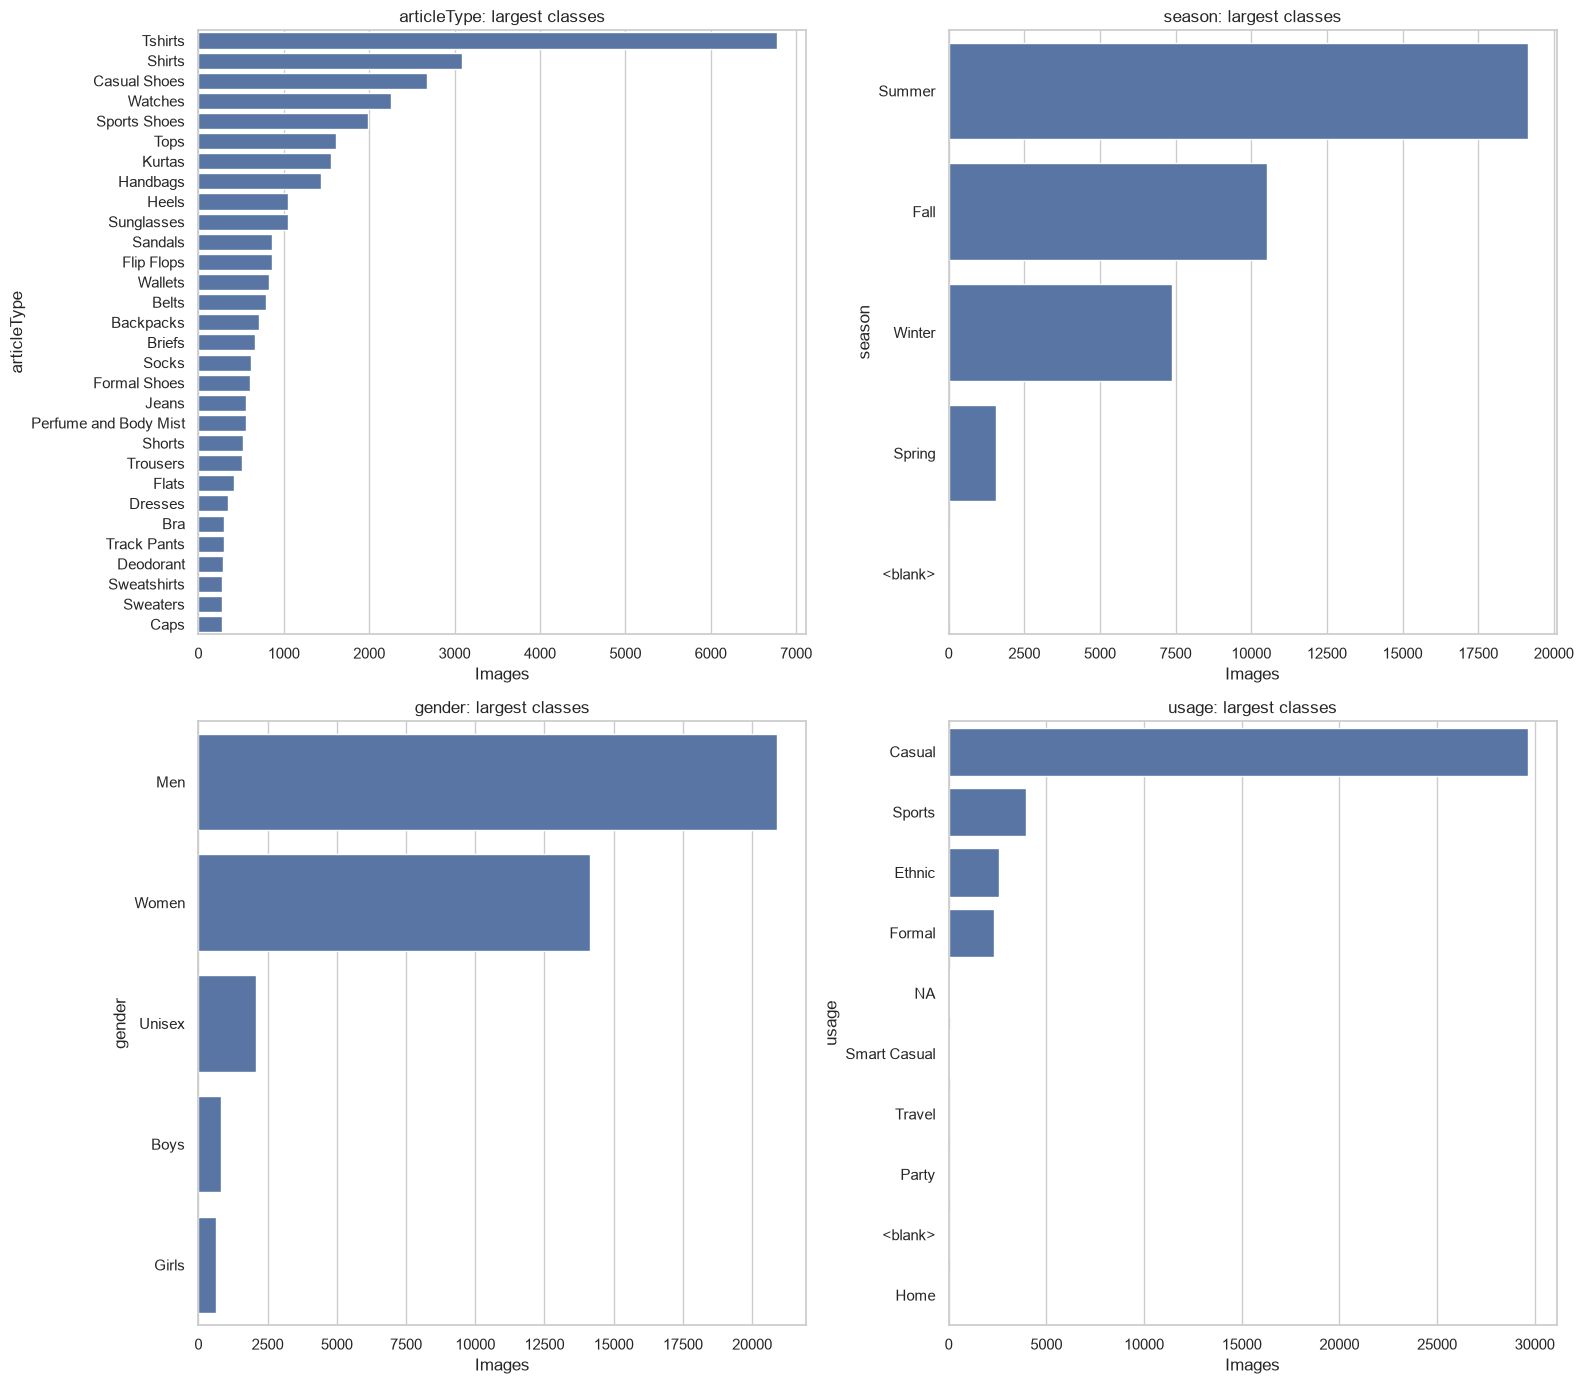

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for target, axis in zip(TARGETS, axes.ravel()):
    counts = usable_metadata[target].replace('', '<blank>').value_counts().head(30)
    sns.barplot(x=counts.values, y=counts.index, ax=axis)
    axis.set_title(f'{target}: largest classes')
    axis.set_xlabel('Images')
plt.tight_layout()

In [6]:
distribution_summary = pd.DataFrame({
    target: {
        'classes': usable_metadata.loc[usable_metadata[target].str.strip().ne(''), target].nunique(),
        'blank': usable_metadata[target].str.strip().eq('').sum(),
        'largest_class_share': usable_metadata.loc[usable_metadata[target].str.strip().ne(''), target].value_counts(normalize=True).iloc[0],
        'classes_below_10': int((usable_metadata.loc[usable_metadata[target].str.strip().ne(''), target].value_counts() < 10).sum()),
    } for target in TARGETS
}).T
distribution_summary

,classes,blank,largest_class_share,classes_below_10
articleType,124.0,0.0,0.175598,32.0
season,4.0,20.0,0.495841,0.0
gender,5.0,0.0,0.541607,0.0
usage,9.0,1.0,0.767547,1.0


## 5.1 Distribution observations

All four targets are imbalanced, so accuracy alone would overstate performance on dominant labels. After unavailable and unreadable images are excluded, `articleType` is the most severe long-tail target: 124 labels remain usable and `Suits` is lost because its only metadata row has no image. Task 1 must therefore report macro F1 and head/medium/tail results in addition to accuracy and top-k accuracy; the task notebook will define support thresholds from frozen training counts.

Season and gender have only four and five labels respectively, but their largest classes account for approximately half of the usable rows. Usage is substantially more skewed because `Casual` dominates. Majority baselines are consequently necessary for context, and validation macro F1 is the primary classifier-selection metric. Twenty blank season values and one genuinely blank usage value are excluded only from their affected tasks; 71 literal `NA` usage strings remain a ninth class because automatic NA conversion is disabled and their meaning has not been reinterpreted without teaching-team confirmation.

# 6. Target Relationships and Confounding

In [7]:
relationship_summary = pd.DataFrame([
    {
        'relationship': f'articleType vs {target}',
        'normalized_mutual_information': normalized_mutual_info_score(
            usable_metadata.loc[usable_metadata[target].str.strip().ne(''), 'articleType'],
            usable_metadata.loc[usable_metadata[target].str.strip().ne(''), target],
        ),
    }
    for target in ('season', 'gender', 'usage')
]).set_index('relationship')
season_by_type = pd.crosstab(usable_metadata.articleType, usable_metadata.season, normalize='index')
season_support = usable_metadata.articleType.value_counts()
concentrated_season_types = (season_by_type.assign(
    support=season_support, dominant_share=season_by_type.max(axis=1),
).loc[lambda frame: frame.support.ge(20)].sort_values('dominant_share', ascending=False).head(15))
display(relationship_summary)
concentrated_season_types.style.background_gradient(cmap='Blues')

,normalized_mutual_information
relationship,
articleType vs season,0.173752
articleType vs gender,0.193672
articleType vs usage,0.253296


season,,Fall,Spring,Summer,Winter,support,dominant_share
articleType,,,,,,,
Nightdress,0.000000,0.000000,0.000000,1.000000,0.000000,39,1.000000
Perfume and Body Mist,0.000000,0.000000,1.000000,0.000000,0.000000,557,1.000000
Suspenders,0.000000,0.000000,0.000000,1.000000,0.000000,40,1.000000
Fragrance Gift Set,0.000000,0.000000,1.000000,0.000000,0.000000,55,1.000000
Deodorant,0.000000,0.000000,0.986348,0.013652,0.000000,293,0.986348
Boxers,0.000000,0.000000,0.000000,0.974359,0.025641,39,0.974359
Watches,0.000000,0.001332,0.000444,0.027975,0.970249,2252,0.970249
Sunglasses,0.000000,0.002865,0.000000,0.029608,0.967526,1047,0.967526
Night suits,0.000000,0.000000,0.000000,0.956522,0.043478,69,0.956522


In [8]:
pd.crosstab(usable_metadata.gender, usable_metadata.usage, normalize='index').style.background_gradient(cmap='Purples')

usage,,Casual,Ethnic,Formal,Home,NA,Party,Smart Casual,Sports,Travel
gender,,,,,,,,,,
Boys,0.000000,0.961916,0.012285,0.000000,0.000000,0.000000,0.000000,0.000000,0.025799,0.000000
Girls,0.000000,0.984496,0.012403,0.000000,0.000000,0.000000,0.000000,0.000000,0.003101,0.000000
Men,0.000048,0.750048,0.004304,0.104868,0.000000,0.001052,0.000000,0.002104,0.137529,0.000048
Unisex,0.000000,0.845192,0.000000,0.000481,0.000481,0.008654,0.000000,0.000000,0.135577,0.009615
Women,0.000000,0.760876,0.173870,0.007486,0.000000,0.002189,0.000918,0.000777,0.053602,0.000282


The normalized crosstabs and normalized mutual information quantify that the targets are not independent of product type: article type has measurable association with season, gender, and especially usage. The concentrated-type table avoids drawing conclusions from an alphabetical slice and shows categories with at least 20 usable images. A classifier can therefore obtain apparently useful season, usage, or gender performance by recognizing article type and applying a catalogue prior, even when the requested attribute is weakly visible in pixels. Task-specific evaluation must examine errors and confidence by article type, and conclusions must describe this confounding rather than claim that images provide direct or objective evidence for season, occasion, or intended gender.

# 7. Visual Inspection

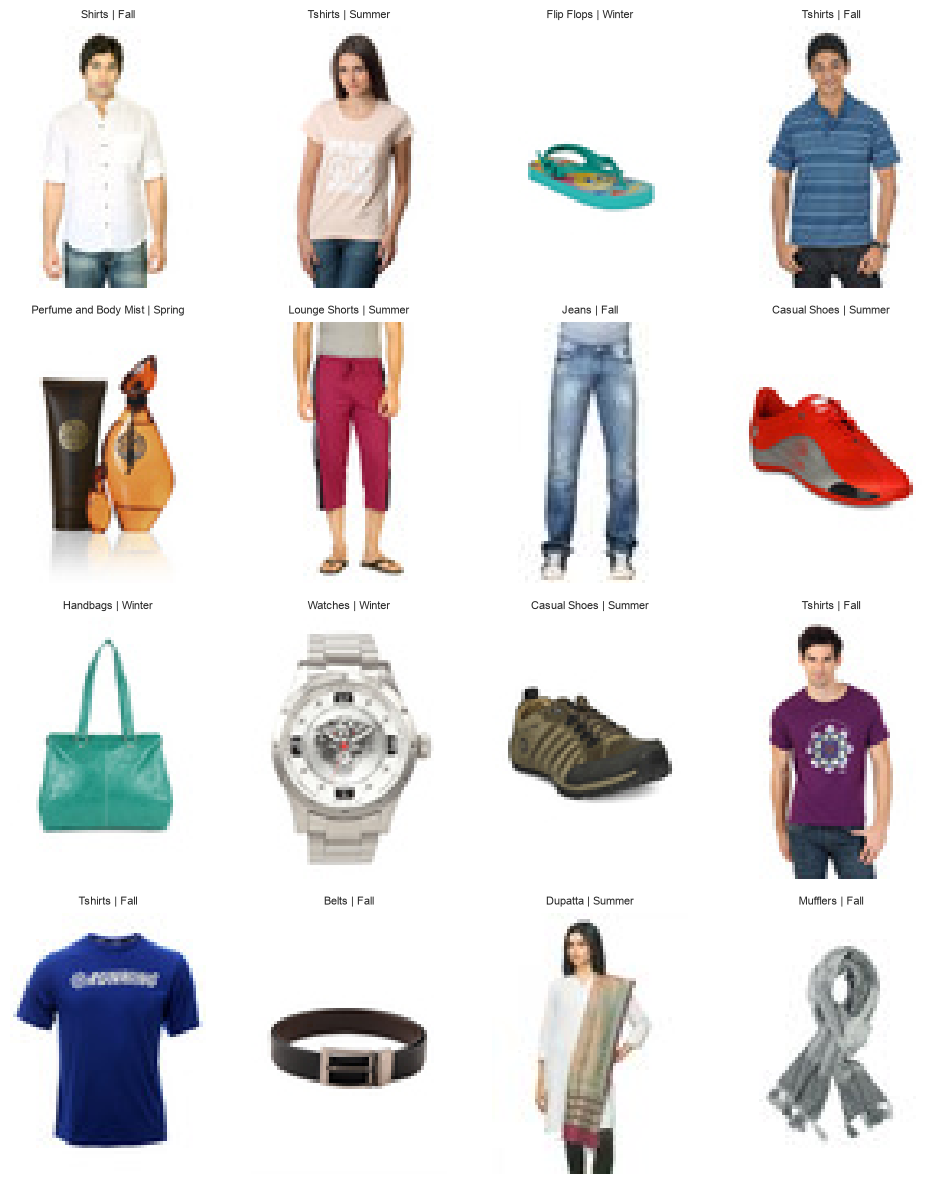

In [9]:
sample = metadata.loc[metadata.has_image].sample(16, random_state=SEED)
fig, axes = plt.subplots(4, 4, figsize=(10, 12))
for (_, row), axis in zip(sample.iterrows(), axes.ravel()):
    with Image.open(row.image_path) as image:
        axis.imshow(image.convert('RGB'))
    axis.set_title(f'{row.articleType} | {row.season}', fontsize=8)
    axis.axis('off')
plt.tight_layout()

In [10]:
dimensions = image_audit.loc[image_audit.decode_error.eq(''), ['width', 'height']].apply(pd.to_numeric)
display(dimensions.describe())
display(image_audit.loc[image_audit.decode_error.eq(''), 'mode'].value_counts())
display(dimensions.value_counts().rename('images').head(10).to_frame())

,width,height
count,38611.000000,38611.000000
mean,59.998550,79.997022
std,0.100751,0.230910
min,53.000000,60.000000
25%,60.000000,80.000000
50%,60.000000,80.000000
75%,60.000000,80.000000
max,60.000000,80.000000


mode
RGB    38268
L        343
Name: count, dtype: int64

images
width height        
60    80       38594
53    80           8
60    60           5
      77           2
      76           1
      75           1

# 8. Duplicate-Safe Frozen Split

The following code joins rows that share a normalized product display name or exact SHA-256 hash, then assigns whole connected groups to deterministic 70/15/15 splits.

In [11]:
def build_group_keys(frame, audit):
    frame = frame.merge(audit[['id', 'sha256', 'decode_error']], on='id', how='left')
    frame = frame.loc[frame.has_image & frame.decode_error.eq('')].reset_index(drop=True)
    frame['name_key'] = frame.productDisplayName.astype('string').str.lower().str.replace(r'\W+', ' ', regex=True).str.strip()
    frame.loc[frame.name_key.eq(''), 'name_key'] = frame.id
    parent = list(range(len(frame)))
    def find(index):
        while parent[index] != index:
            parent[index] = parent[parent[index]]; index = parent[index]
        return index
    def union(left, right):
        left_root, right_root = find(left), find(right)
        if left_root != right_root: parent[right_root] = left_root
    for column in ('name_key', 'sha256'):
        values = frame[column].astype('string').fillna('')
        for value, indices in values.groupby(values, sort=False).groups.items():
            if not value or len(indices) < 2: continue
            first = int(indices[0])
            for index in indices[1:]: union(first, int(index))
    frame['group_key'] = [f'group_{find(index)}' for index in range(len(frame))]
    return frame

def create_frozen_split(frame, audit):
    grouped = build_group_keys(frame, audit)
    first = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=SEED)
    _, holdout_index = next(first.split(grouped, groups=grouped.group_key))
    holdout = grouped.iloc[holdout_index]
    second = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=SEED + 1)
    _, test_relative = next(second.split(holdout, groups=holdout.group_key))
    grouped['split'] = 'train'
    grouped.loc[grouped.id.isin(holdout.id), 'split'] = 'validation'
    grouped.loc[grouped.id.isin(holdout.iloc[test_relative].id), 'split'] = 'test'
    return grouped[['id', 'group_key', 'split']]

def enforce_training_label_coverage(frame, split_frame):
    """Move whole duplicate groups to train when a label has no train example."""
    revised = split_frame.copy()
    changes = []
    for target in TARGETS:
        joined = frame[['id', target]].merge(revised, on='id', validate='one_to_one')
        valid = joined[target].astype('string').str.strip().ne('')
        train_labels = set(joined.loc[valid & joined.split.eq('train'), target])
        missing_labels = sorted(set(joined.loc[valid, target]) - train_labels)
        for label in missing_labels:
            groups = joined.loc[valid & joined[target].eq(label), 'group_key'].unique()
            move_mask = revised.group_key.isin(groups) & ~revised.split.eq('train')
            changes.append({
                'target': target, 'label': label,
                'groups_moved': int(len(groups)), 'rows_moved': int(move_mask.sum()),
            })
            revised.loc[revised.group_key.isin(groups), 'split'] = 'train'
    return revised, pd.DataFrame(changes)

if SPLIT_PATH.exists():
    splits = pd.read_csv(SPLIT_PATH, dtype={'id': 'string'})
elif image_audit is None:
    raise RuntimeError('Complete the full image audit before creating splits')
else:
    splits = create_frozen_split(metadata, image_audit)
splits, coverage_repairs = enforce_training_label_coverage(metadata, splits)
splits.to_csv(SPLIT_PATH, index=False)
if not coverage_repairs.empty:
    display(coverage_repairs)
splits['split'].value_counts(), splits.groupby('group_key')['split'].nunique().max()

(split
 train         27051
 validation     5842
 test           5718
 Name: count, dtype: int64,
 np.int64(1))

In [12]:
split_metadata = usable_metadata.merge(splits, on='id', validate='one_to_one')
split_counts = splits.split.value_counts().reindex(['train', 'validation', 'test'])
split_summary = pd.DataFrame({
    'rows': split_counts,
    'percent': 100 * split_counts / len(splits),
    'groups': splits.groupby('split').group_key.nunique().reindex(split_counts.index),
})
split_quality_rows = []
for target in TARGETS:
    valid = split_metadata[target].str.strip().ne('')
    target_frame = split_metadata.loc[valid]
    overall_share = target_frame[target].value_counts(normalize=True)
    train_labels = set(target_frame.loc[target_frame.split.eq('train'), target])
    for split_name in ('train', 'validation', 'test'):
        partition = target_frame.loc[target_frame.split.eq(split_name), target]
        partition_share = partition.value_counts(normalize=True).reindex(overall_share.index, fill_value=0)
        split_quality_rows.append({
            'target': target, 'split': split_name, 'usable_rows': len(partition),
            'labels_present': partition.nunique(),
            'labels_absent_from_training': len(set(partition) - train_labels),
            'max_class_share_drift_pp': 100 * (partition_share - overall_share).abs().max(),
        })
split_quality = pd.DataFrame(split_quality_rows)
display(split_summary.round({'percent': 2}))
display(pd.DataFrame({
    'groups': [splits.group_key.nunique()],
    'largest_group_rows': [splits.groupby('group_key').size().max()],
    'groups_crossing_splits': [splits.groupby('group_key').split.nunique().gt(1).sum()],
}))
split_quality.round({'max_class_share_drift_pp': 2})

,rows,percent,groups
split,,,
train,27051,70.06,18987
validation,5842,15.13,4064
test,5718,14.81,4067


,groups,largest_group_rows,groups_crossing_splits
0,27118,82,0


,target,split,usable_rows,labels_present,labels_absent_from_training,max_class_share_drift_pp
0,articleType,train,27051,124,0,0.26
1,articleType,validation,5842,104,0,0.80
2,articleType,test,5718,101,0,0.71
3,season,train,27038,4,0,0.28
4,season,validation,5838,4,0,0.57
5,season,test,5715,4,0,0.73
6,gender,train,27051,5,0,0.32
7,gender,validation,5842,5,0,0.54
8,gender,test,5718,5,0,1.07
9,usage,train,27050,9,0,0.20


The frozen manifest contains 27,051 training rows (70.06%), 5,842 validation rows (15.13%), and 5,718 internal-test rows (14.81%). Its 27,118 connected groups have a maximum size of 82 rows, and zero groups cross partitions. The small deviation from an exact 70/15/15 row ratio is expected because complete groups, rather than individual images, are assigned together. Across targets and partitions, the largest absolute shift in any class share from the usable-data distribution is approximately 1.40 percentage points, so group isolation did not create severe distribution drift.

| Target | Usable labels | Train labels | Validation labels | Test labels | Unseen validation/test labels |
|---|---:|---:|---:|---:|---:|
| `articleType` | 124 | 124 | 104 | 101 | 0 / 0 |
| `season` | 4 | 4 | 4 | 4 | 0 / 0 |
| `gender` | 5 | 5 | 5 | 5 | 0 / 0 |
| `usage` | 9 | 9 | 8 | 8 | 0 / 0 |

Rare labels need not occur in every evaluation partition, but every validation or test label is represented in training. This makes metrics computable without leaking rows across related-product groups. `splits.csv` is now the team contract and must not be regenerated to improve a score.

# 9. Training-Only RGB Normalization

In [13]:
def compute_training_normalisation(frame, split_frame):
    joined = frame.merge(split_frame, on='id', validate='one_to_one')
    paths = joined.loc[joined.split.eq('train'), 'image_path']
    channel_sum = np.zeros(3, dtype=np.float64)
    channel_square_sum = np.zeros(3, dtype=np.float64)
    pixel_count = 0
    for path in paths:
        with Image.open(path) as image:
            array = np.transpose(preprocess_image(image), (1, 2, 0)).astype(np.float64)
        channel_sum += array.sum(axis=(0, 1))
        channel_square_sum += np.square(array).sum(axis=(0, 1))
        pixel_count += array.shape[0] * array.shape[1]
    mean = channel_sum / pixel_count
    std = np.sqrt(channel_square_sum / pixel_count - np.square(mean))
    return {'mean': mean.tolist(), 'std': std.tolist(), 'image_size': list(IMAGE_SIZE)}

if NORMALISATION_PATH.exists():
    with NORMALISATION_PATH.open(encoding='utf-8') as handle:
        normalisation = json.load(handle)
else:
    normalisation = compute_training_normalisation(metadata, splits)
    NORMALISATION_PATH.write_text(json.dumps(normalisation, indent=2), encoding='utf-8')
normalisation

{'mean': [0.8502750031713799, 0.8334922756826109, 0.8277549238925582],
 'std': [0.26589262549701936, 0.2775687167185324, 0.28121521485116663],
 'image_size': [96, 128]}

# 10. Decisions and Limitations

All usable images are converted to RGB so the 343 grayscale files and ordinary RGB files share one three-channel input contract. Images are resized from the predominantly 60×80 catalogue format to 96×128 (width × height) with bilinear interpolation. This standardizes tensor shapes while preserving the original 3:4 aspect ratio, but it cannot recover fine detail absent from the small source images. The training-channel statistics are mean `[0.8503, 0.8335, 0.8278]` and standard deviation `[0.2659, 0.2776, 0.2812]`; they were fitted only on frozen training rows. Augmentation and any class weighting or feature fitting are likewise restricted to training data, while validation and test transforms remain deterministic.

To reduce optimistic leakage, rows sharing a normalized product display name or exact SHA-256 image hash are joined into connected groups before the deterministic 70/15/15 assignment. This guards against identical files and repeated product listings appearing on both sides of evaluation, although name matching and exact hashes cannot detect every near-duplicate or visually related product. Exact duplicates with contradictory labels are retained as documented label noise, and their groups remain isolated. The split also moves an entire group to training when necessary to ensure that every evaluated label is learnable; it never moves individual related rows independently.

Classifier candidates are selected by validation macro F1 because all targets are imbalanced; accuracy, top-k accuracy where appropriate, calibration, robustness, latency, size, and per-class evidence support the final judgement. Blank labels are removed only for the affected target, and literal `NA` usage is preserved. Finally, season and occasion are subjective and may not be visually identifiable, while an item's marketed gender label is a catalogue attribute rather than a property of a person. Reported results must therefore be interpreted as prediction of this dataset's merchandising metadata, with subgroup and failure analysis used to expose article-type shortcuts and ambiguous cases.